# Mental Health in the Workplace (2020–2024)


**Dataset:** 10,000 records · 34 features · 20 countries  
**Target Variable:** `burnout_risk_score` *(Primary — Regression)*  &nbsp;|&nbsp; `stress_level` *(Secondary — Classification)*

---


### Mount Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install dependencies & import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("Libraries loaded")


Libraries loaded


### Load & inspect the data

In [3]:
df = pd.read_csv('/content/drive/MyDrive/dataset/mental_health_workplace.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")


Shape: (10000, 34)

Column names:
['record_id', 'year', 'country', 'industry', 'job_role', 'employment_type', 'work_model', 'company_size', 'age_group', 'gender', 'years_of_experience', 'annual_salary_usd', 'weekly_work_hours', 'weekly_overtime_hours', 'mental_health_condition', 'has_diagnosis', 'treatment_type', 'stress_level', 'burnout_risk_score', 'work_life_balance_score', 'productivity_score', 'job_satisfaction_score', 'absenteeism_days_per_year', 'employer_support_level', 'mental_health_policy_exists', 'eap_available', 'used_eap', 'workplace_stigma_felt', 'manager_support_score', 'team_collaboration_score', 'intention_to_leave', 'remote_work_preference', 'exercise_days_per_week', 'sleep_hours_per_night']

Data types:
record_id                       object
year                             int64
country                         object
industry                        object
job_role                        object
employment_type                 object
work_model                      o

In [4]:
df.head()


,record_id,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
0,MHW0000001,2024,South Korea,Government & Public Sector,Manager/Team Lead,Contract,On-site,Large (1001-5000),18-24,Male,...,Yes,Yes,No,NaN,9.9,9.6,Likely,Prefer On-site,7,7.1
1,MHW0000002,2023,Australia,Education,Software Engineer,Full-time,On-site,Medium (201-1000),45-54,Male,...,Partial,Yes,No,Severe,4.1,5.2,Unlikely,No Preference,4,6.4
2,MHW0000003,2023,Canada,Technology,Marketing Specialist,Full-time,Hybrid,Small (51-200),45-54,Male,...,Yes,Yes,Yes,NaN,9.0,5.9,Very Unlikely,Prefer On-site,3,7.3
3,MHW0000004,2020,Brazil,Hospitality,Nurse,Full-time,Hybrid,Small (51-200),35-44,Male,...,Yes,No,NaN,Severe,3.6,9.2,Neutral,Prefer Remote,2,6.1
4,MHW0000005,2020,USA,Finance & Banking,Manager/Team Lead,Full-time,On-site,Enterprise (5000+),25-34,Non-binary,...,Partial,Yes,No,NaN,3.8,7.8,Unlikely,No Preference,2,7.5


In [5]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': pct})


=== Missing Values ===


,Missing Count,Missing %
used_eap,4812,48.12
mental_health_condition,3350,33.50
workplace_stigma_felt,2832,28.32
employer_support_level,1018,10.18


In [6]:
df.describe()


,year,years_of_experience,annual_salary_usd,weekly_work_hours,weekly_overtime_hours,burnout_risk_score,work_life_balance_score,productivity_score,job_satisfaction_score,absenteeism_days_per_year,manager_support_score,team_collaboration_score,exercise_days_per_week,sleep_hours_per_night
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,2022.151300,14.492500,86779.311900,45.155000,6.564600,4.027030,6.439440,6.435220,5.869680,10.261200,6.506920,7.04170,2.727300,6.789090
std,1.334086,10.053509,24022.505197,8.629115,6.806692,2.304458,1.622201,1.569136,1.757524,6.918682,2.022469,1.73075,1.813688,1.095441
min,2020.000000,0.000000,36140.000000,20.000000,0.000000,1.000000,1.200000,2.100000,1.100000,0.000000,3.000000,4.00000,0.000000,3.000000
25%,2021.000000,6.000000,68216.000000,39.000000,0.000000,2.200000,5.200000,5.400000,4.600000,4.000000,4.800000,5.60000,1.000000,6.000000
50%,2022.000000,13.000000,84816.000000,45.000000,5.000000,3.700000,6.500000,6.400000,5.900000,10.000000,6.500000,7.10000,3.000000,6.800000
75%,2023.000000,21.000000,102633.250000,51.000000,11.000000,5.500000,7.700000,7.700000,7.300000,15.000000,8.300000,8.50000,4.000000,7.500000
max,2024.000000,44.000000,177599.000000,79.000000,39.000000,10.000000,9.900000,9.500000,9.000000,36.000000,10.000000,10.00000,7.000000,10.000000


### Encode categorical columns for correlation

Pearson correlation only works on numeric data, so we encode:
- **Ordinal** columns with meaningful order (e.g. stress level: Very Low → 1, Very Severe → 5)
- **Binary** columns as 0 / 1
- **Nominal** columns with LabelEncoder (no natural order — treat with care in modelling)


In [7]:
df_enc = df.copy()
df_enc.drop(columns=['record_id'], inplace=True)

# ── Ordinal mappings (order matters) ──────────────────────────────────────────
ordinal_maps = {
    'stress_level': {
        'Very Low': 1, 'Low': 2, 'Moderate': 3, 'High': 4, 'Very Severe': 5
    },
    'intention_to_leave': {
        'Very Unlikely': 1, 'Unlikely': 2, 'Neutral': 3, 'Likely': 4, 'Very Likely': 5
    },
    'employer_support_level': {
        'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4
    },
    'workplace_stigma_felt': {
        'None': 1, 'Mild': 2, 'Moderate': 3, 'Severe': 4
    },
    'company_size': {
        'Small (<50)': 1, 'Medium (51-200)': 2,
        'Medium (201-1000)': 3, 'Large (1001-5000)': 4, 'Enterprise (5001+)': 5
    },
}
for col, mapping in ordinal_maps.items():
    df_enc[col] = df_enc[col].map(mapping)

# ── Binary mappings ────────────────────────────────────────────────────────────
binary_maps = {
    'has_diagnosis':               {'No': 0, 'Yes': 1},
    'mental_health_policy_exists': {'No': 0, 'Partial': 0.5, 'Yes': 1},
    'eap_available':               {'No': 0, 'Yes': 1},
    'used_eap':                    {'No': 0, 'Yes': 1},
}
for col, mapping in binary_maps.items():
    df_enc[col] = df_enc[col].map(mapping)

# ── Nominal: LabelEncode remaining string columns ─────────────────────────────
le = LabelEncoder()
nominal_cols = [c for c in df_enc.columns if df_enc[c].dtype == 'object'
                or str(df_enc[c].dtype) == 'string']
print(f"Nominal columns to label-encode: {nominal_cols}")

for col in nominal_cols:
    df_enc[col] = df_enc[col].fillna('Unknown')
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# ── Fill remaining NaN with median ────────────────────────────────────────────
df_enc = df_enc.apply(pd.to_numeric, errors='coerce')
df_enc.fillna(df_enc.median(), inplace=True)

print(f"\nEncoded dataframe shape: {df_enc.shape}")
df_enc.head()


Nominal columns to label-encode: ['country', 'industry', 'job_role', 'employment_type', 'work_model', 'age_group', 'gender', 'mental_health_condition', 'treatment_type', 'remote_work_preference']

Encoded dataframe shape: (10000, 33)


,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,years_of_experience,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
0,2024,15,4,10,0,1,4.0,0,1,0,...,1.0,1,0.0,3.0,9.9,9.6,4,1,7,7.1
1,2023,0,2,18,2,1,3.0,3,1,19,...,0.5,1,0.0,4.0,4.1,5.2,2,0,4,6.4
2,2023,2,13,11,2,0,3.0,3,1,19,...,1.0,1,1.0,3.0,9.0,5.9,1,1,3,7.3
3,2020,1,6,12,2,0,3.0,2,1,12,...,1.0,0,0.0,4.0,3.6,9.2,3,2,2,6.1
4,2020,19,3,10,2,1,3.0,1,2,5,...,0.5,1,0.0,3.0,3.8,7.8,2,0,2,7.5


### Compute Pearson correlation matrix

In [8]:
corr = df_enc.corr()
print(f"Correlation matrix shape: {corr.shape}")


Correlation matrix shape: (33, 33)


### Correlation Heatmap

- 🟠 **Orange dashed border** = Primary target: `burnout_risk_score`  
- 🔵 **Blue dashed border** = Secondary target: `stress_level`  
- Right panel shows the bar chart of all features correlated with the primary target.


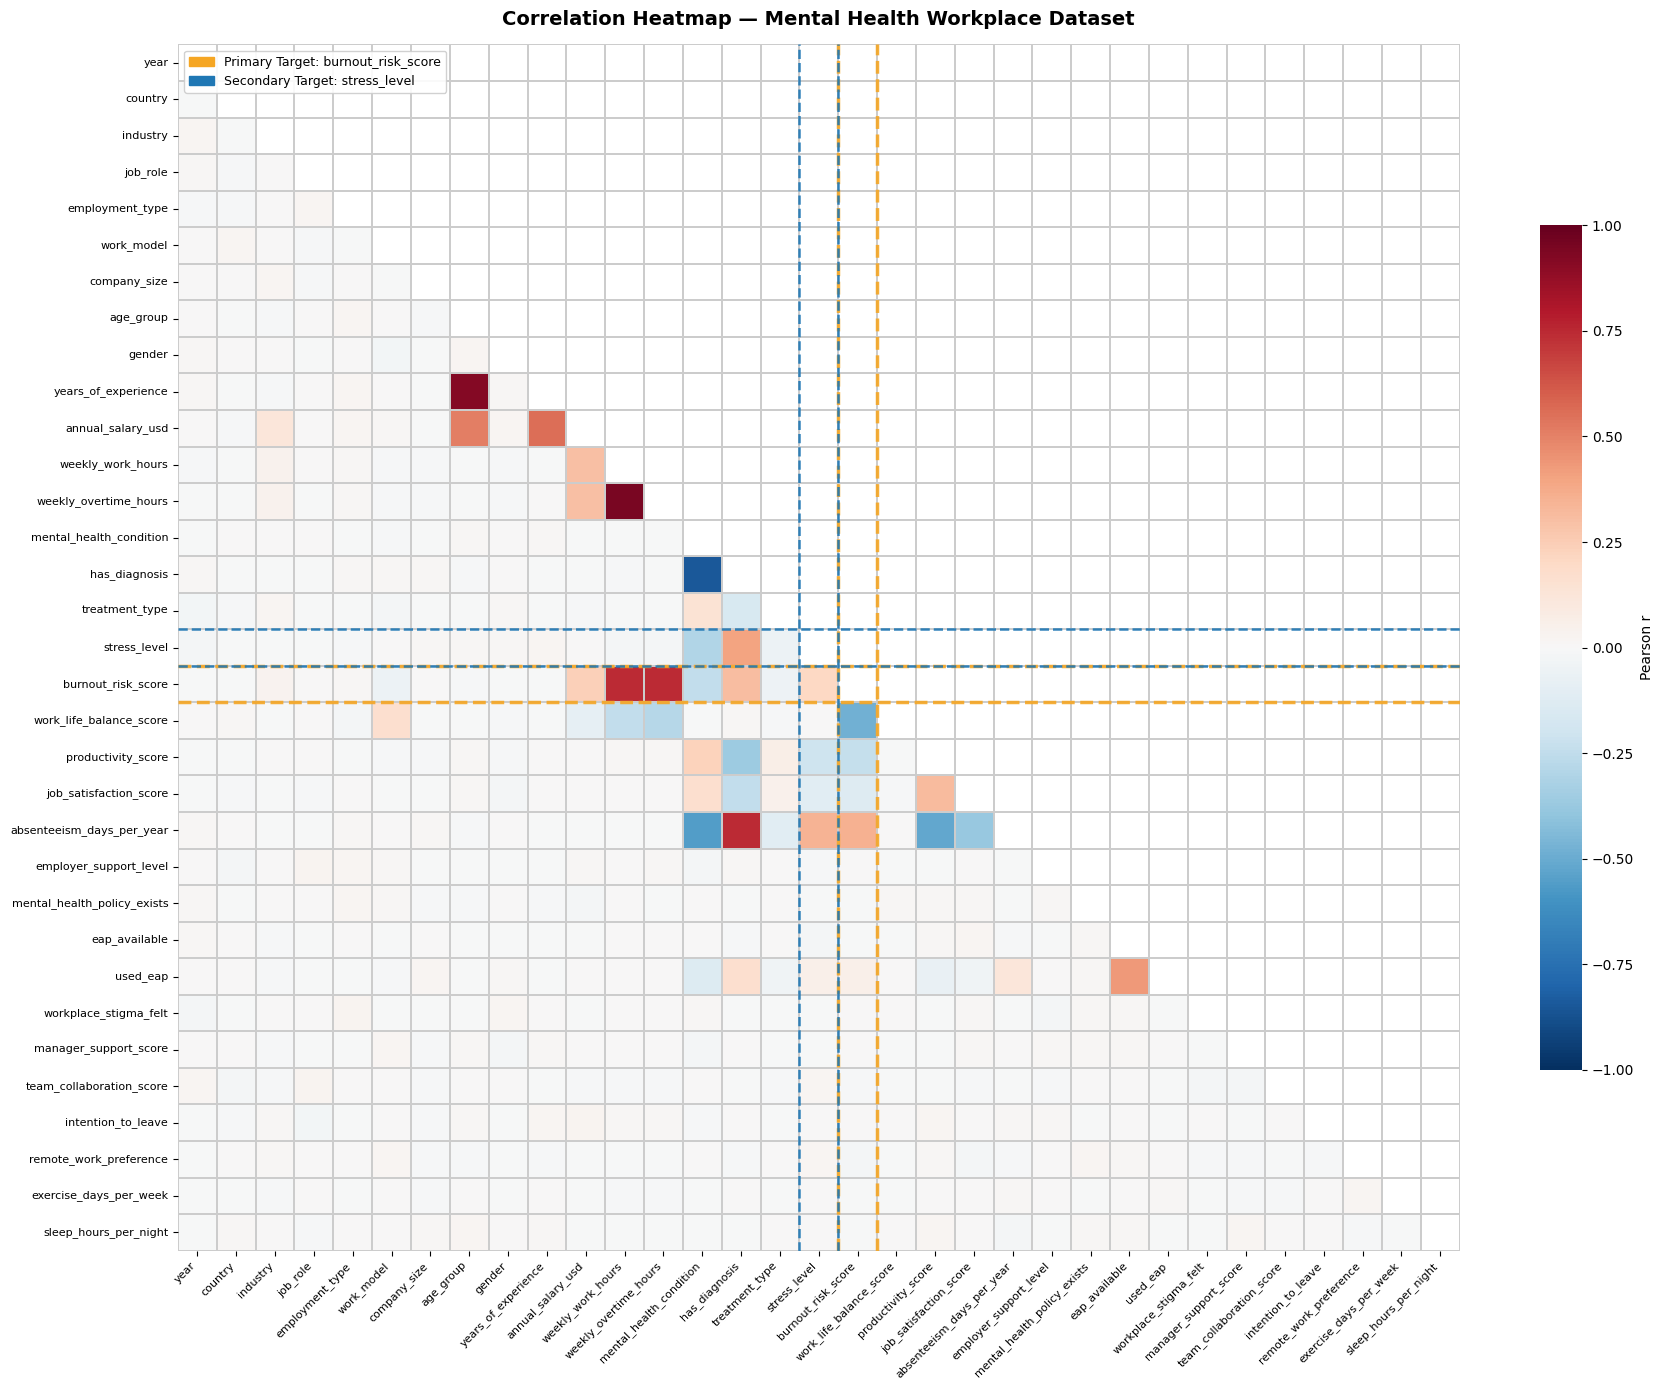

In [18]:
#  ── Correlation matrix ─────────────────────────────────────────────────────────
TARGET           = 'burnout_risk_score'   # PRIMARY  (orange)
SECONDARY_TARGET = 'stress_level'         # SECONDARY (blue)

corr = df_enc.corr()
cols_list = corr.columns.tolist()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap(
    corr,
    mask=mask,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    linecolor='#cccccc',
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
)

ax.set_title('Correlation Heatmap — Mental Health Workplace Dataset',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Highlight target variables
for target, color, lw in [(TARGET, '#f5a623', 2.5), (SECONDARY_TARGET, '#1f77b4', 1.8)]:
    if target in cols_list:
        idx = cols_list.index(target)
        ax.axvline(x=idx,     color=color, lw=lw, linestyle='--', alpha=0.9)
        ax.axvline(x=idx + 1, color=color, lw=lw, linestyle='--', alpha=0.9)
        ax.axhline(y=idx,     color=color, lw=lw, linestyle='--', alpha=0.9)
        ax.axhline(y=idx + 1, color=color, lw=lw, linestyle='--', alpha=0.9)

patches = [
    mpatches.Patch(color='#f5a623', label=f'Primary Target: {TARGET}'),
    mpatches.Patch(color='#1f77b4', label=f'Secondary Target: {SECONDARY_TARGET}'),
]
ax.legend(handles=patches, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

### Top correlations with the primary target

In [16]:
print(f"{'='*55}")
print(f"Top correlations with PRIMARY target: {TARGET}")
print('='*55)

top = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(15)
results = []
for feat, abs_val in top.items():
    raw_val = corr[TARGET][feat]
    direction = 'Positive' if raw_val > 0 else 'Negative'
    results.append({'Feature': feat, 'Pearson r': round(raw_val, 4), 'Direction': direction})

pd.DataFrame(results)


Top correlations with PRIMARY target: burnout_risk_score


,Feature,Pearson r,Direction
0,weekly_work_hours,0.7472,Positive
1,weekly_overtime_hours,0.7469,Positive
2,work_life_balance_score,-0.4830,Negative
3,absenteeism_days_per_year,0.3549,Positive
4,has_diagnosis,0.3092,Positive
5,mental_health_condition,-0.2435,Negative
6,annual_salary_usd,0.2407,Positive
7,productivity_score,-0.2391,Negative
8,stress_level,0.2085,Positive
9,job_satisfaction_score,-0.1311,Negative
